tensor([-4.3711e-08,  1.0000e+00])


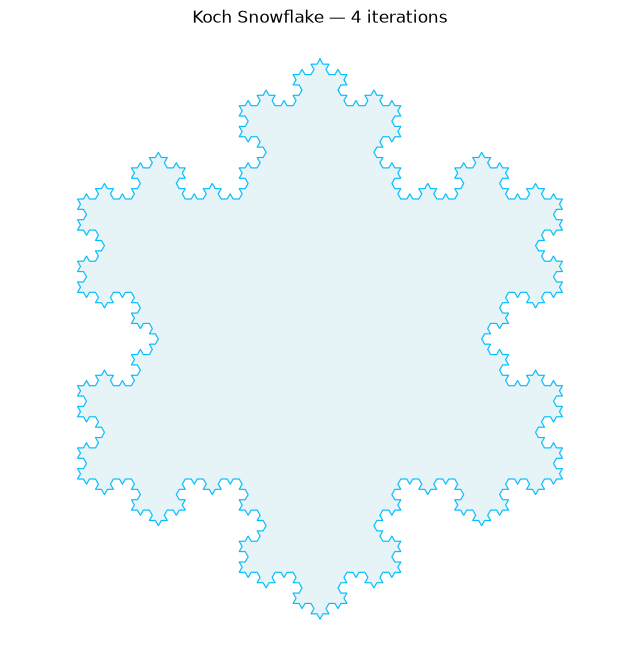

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


##step 1: represent the triangle as a tensor
##values given by unit circle e.g.
#botom left : 210deg on unit circle, or (cos210, sin210) = (-0.866, -.05)
points = torch.tensor([
    [0.0, 1.0],        #top
    [-0.866, -0.5],    #bottom left
    [0.866, -0.5],     #bottom right
    [0.0, 1.0],        #back to top —> closes the shape!
], dtype=torch.float32, device=device)

def rotate(vec, theta):
    #vec: tensor of shape (2,) —> a single (x, y) vector
    cos_t = torch.cos(torch.tensor(theta, dtype=torch.float32))
    sin_t = torch.sin(torch.tensor(theta, dtype=torch.float32))
    x, y = vec[0], vec[1]
    new_x = x * cos_t - y * sin_t
    new_y = x * sin_t + y * cos_t
    return torch.stack([new_x, new_y])

def koch_one_segment(a, b):
    #a, b: each a tensor of shape (2,)

    #point 1/3 of the way from a to b
    p1 = a + (b - a) / 3.0

    #point 2/3 of the way from a to b
    p2 = a + (b - a) * 2.0 / 3.0

    #vector from p1 to p2
    v = p2 - p1

    #rotate that vector by -60 degrees (outward bump)
    theta = -np.pi / 3.0
    rv = rotate(v, theta)

    #peak point
    peak = p1 + rv

    #stack the 5 points into one tensor of shape (5, 2)
    return torch.stack([a, p1, peak, p2, b])

#a ────────────── b
# to: 
#     peak
#      /\
#     /  \
#a---p1  p2---b

def koch_iteration(points):
    new_points_list = []
    for i in range(len(points) - 1):
        a = points[i]
        b = points[i + 1]
        segment_result = koch_one_segment(a, b)   #shape (5, 2)
        #drop the last point (b) so it isn't duplicated
        #it'll be the start of the next segment
        new_points_list.append(segment_result[:-1])
    new_points_list.append(points[-1:])   #close the shape at the very end
    return torch.cat(new_points_list, dim=0)


#test: rotating (1, 0) by 90 degrees should give roughly (0, 1)
test_vec = torch.tensor([1.0, 0.0])
print(rotate(test_vec, np.pi / 2))

pts = points
n_iterations = 4

for i in range(n_iterations):
    pts = koch_iteration(pts)

pts_np = pts.cpu().numpy()

plt.figure(figsize=(8, 8))
plt.plot(pts_np[:, 0], pts_np[:, 1], color='deepskyblue', linewidth=0.8)
plt.fill(pts_np[:, 0], pts_np[:, 1], color='lightblue', alpha=0.3)
plt.axis('equal')
plt.axis('off')
plt.title(f"Koch Snowflake — {n_iterations} iterations")
plt.show()